# Loading Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importing the dataset using pandas

In [2]:
# this will allow us to open up the file

with open('parkinsons_updrs.names', 'r') as file:
    parkinsons_info = file.read()

print(parkinsons_info)

Parkinsons Telemonitoring Data Set  

Abstract: Oxford Parkinson's Disease Telemonitoring Dataset


Data Set Characteristics:  Multivariate
Attribute Characteristics:  Integer, Real
Associated Tasks:  Regression
Number of Instances:  5875
Number of Attributes:  26
Area:  Life
Date Donated:  2009-10-29


SOURCE:

The dataset was created by Athanasios Tsanas (tsanasthanasis '@' gmail.com) 
and Max Little (littlem '@' physics.ox.ac.uk) of the University of Oxford, in 
collaboration with 10 medical centers in the US and Intel Corporation who 
developed the telemonitoring device to record the speech signals. The 
original study used a range of linear and nonlinear regression methods to 
predict the clinician's Parkinson's disease symptom score on the UPDRS scale.



DATA SET INFORMATION:

This dataset is composed of a range of biomedical voice measurements from 42 
people with early-stage Parkinson's disease recruited to a six-month trial of 
a telemonitoring device for remote symptom progr

In [3]:
df = pd.read_csv('parkinsons_updrs.data')
df.head()

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


# Basic EDA (Exploratory Data Analysis) on Data Frame

In [4]:
df.columns # this will give us the column names

Index(['subject#', 'age', 'sex', 'test_time', 'motor_UPDRS', 'total_UPDRS',
       'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP',
       'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE'],
      dtype='object')

In [5]:
df.columns.tolist() # this will give us the column names without the Index and dtype

['subject#',
 'age',
 'sex',
 'test_time',
 'motor_UPDRS',
 'total_UPDRS',
 'Jitter(%)',
 'Jitter(Abs)',
 'Jitter:RAP',
 'Jitter:PPQ5',
 'Jitter:DDP',
 'Shimmer',
 'Shimmer(dB)',
 'Shimmer:APQ3',
 'Shimmer:APQ5',
 'Shimmer:APQ11',
 'Shimmer:DDA',
 'NHR',
 'HNR',
 'RPDE',
 'DFA',
 'PPE']

In [6]:
df.info() # using info() to get an idea of non-null count, data type 
          # we do not have to use isnull().sum() because there aren't any nulls in the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5875 entries, 0 to 5874
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   subject#       5875 non-null   int64  
 1   age            5875 non-null   int64  
 2   sex            5875 non-null   int64  
 3   test_time      5875 non-null   float64
 4   motor_UPDRS    5875 non-null   float64
 5   total_UPDRS    5875 non-null   float64
 6   Jitter(%)      5875 non-null   float64
 7   Jitter(Abs)    5875 non-null   float64
 8   Jitter:RAP     5875 non-null   float64
 9   Jitter:PPQ5    5875 non-null   float64
 10  Jitter:DDP     5875 non-null   float64
 11  Shimmer        5875 non-null   float64
 12  Shimmer(dB)    5875 non-null   float64
 13  Shimmer:APQ3   5875 non-null   float64
 14  Shimmer:APQ5   5875 non-null   float64
 15  Shimmer:APQ11  5875 non-null   float64
 16  Shimmer:DDA    5875 non-null   float64
 17  NHR            5875 non-null   float64
 18  HNR     

In [7]:
df.describe().transpose() # Basic descriptive stats on dataset

,count,mean,std,min,25%,50%,75%,max
subject#,5875.0,21.494128,12.372279,1.000000,10.000000,22.000000,33.000000,42.000000
age,5875.0,64.804936,8.821524,36.000000,58.000000,65.000000,72.000000,85.000000
sex,5875.0,0.317787,0.465656,0.000000,0.000000,0.000000,1.000000,1.000000
test_time,5875.0,92.863722,53.445602,-4.262500,46.847500,91.523000,138.445000,215.490000
motor_UPDRS,5875.0,21.296229,8.129282,5.037700,15.000000,20.871000,27.596500,39.511000
total_UPDRS,5875.0,29.018942,10.700283,7.000000,21.371000,27.576000,36.399000,54.992000
Jitter(%),5875.0,0.006154,0.005624,0.000830,0.003580,0.004900,0.006800,0.099990
Jitter(Abs),5875.0,0.000044,0.000036,0.000002,0.000022,0.000035,0.000053,0.000446
Jitter:RAP,5875.0,0.002987,0.003124,0.000330,0.001580,0.002250,0.003290,0.057540
Jitter:PPQ5,5875.0,0.003277,0.003732,0.000430,0.001820,0.002490,0.003460,0.069560


In [8]:
df.corr().round(2) # this gives us correlation table. Kind of hard on the eyes

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
subject#,1.00,-0.03,0.29,-0.00,0.25,0.25,0.14,0.08,0.12,0.14,...,0.14,0.11,0.14,0.17,0.11,0.17,-0.21,0.15,0.10,0.16
age,-0.03,1.00,-0.04,0.02,0.27,0.31,0.02,0.04,0.01,0.01,...,0.11,0.10,0.09,0.14,0.10,0.01,-0.10,0.09,-0.09,0.12
sex,0.29,-0.04,1.00,-0.01,-0.03,-0.10,0.05,-0.15,0.08,0.09,...,0.06,0.04,0.06,0.02,0.04,0.17,-0.00,-0.16,-0.17,-0.10
test_time,-0.00,0.02,-0.01,1.00,0.07,0.08,-0.02,-0.01,-0.03,-0.02,...,-0.03,-0.03,-0.04,-0.04,-0.03,-0.03,0.04,-0.04,0.02,-0.00
motor_UPDRS,0.25,0.27,-0.03,0.07,1.00,0.95,0.08,0.05,0.07,0.08,...,0.11,0.08,0.09,0.14,0.08,0.07,-0.16,0.13,-0.12,0.16
total_UPDRS,0.25,0.31,-0.10,0.08,0.95,1.00,0.07,0.07,0.06,0.06,...,0.10,0.08,0.08,0.12,0.08,0.06,-0.16,0.16,-0.11,0.16
Jitter(%),0.14,0.02,0.05,-0.02,0.08,0.07,1.00,0.87,0.98,0.97,...,0.72,0.66,0.69,0.65,0.66,0.83,-0.68,0.43,0.23,0.72
Jitter(Abs),0.08,0.04,-0.15,-0.01,0.05,0.07,0.87,1.00,0.84,0.79,...,0.66,0.62,0.62,0.59,0.62,0.70,-0.71,0.55,0.35,0.79
Jitter:RAP,0.12,0.01,0.08,-0.03,0.07,0.06,0.98,0.84,1.00,0.95,...,0.69,0.65,0.66,0.60,0.65,0.79,-0.64,0.38,0.21,0.67
Jitter:PPQ5,0.14,0.01,0.09,-0.02,0.08,0.06,0.97,0.79,0.95,1.00,...,0.73,0.68,0.73,0.67,0.68,0.86,-0.66,0.38,0.18,0.66


<Axes: title={'center': 'Correlation Heatmap on Numerical Data'}>

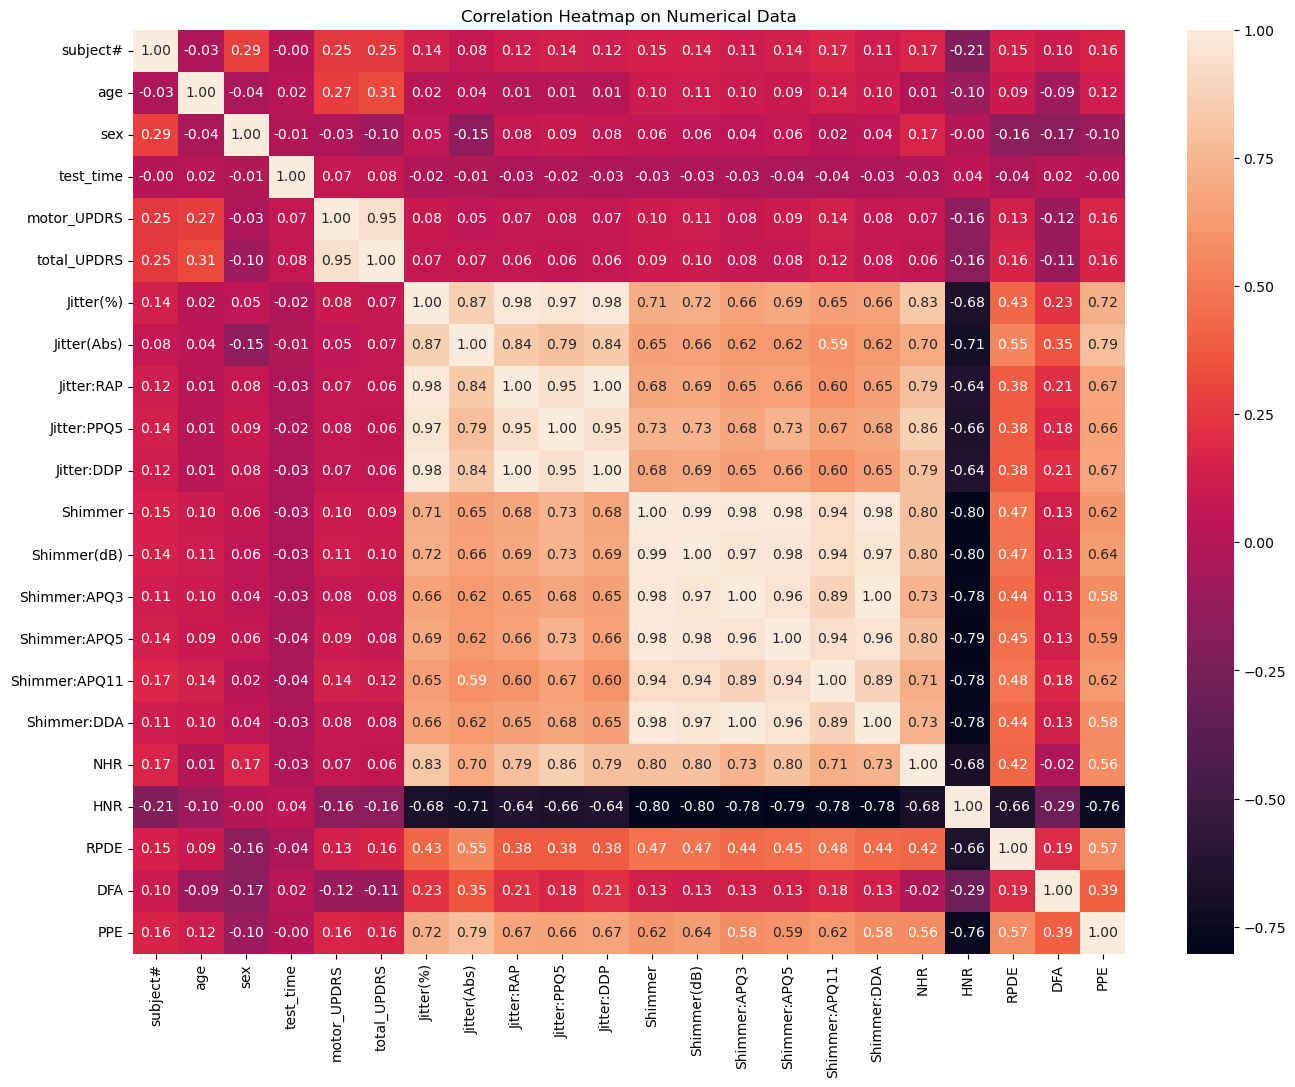

In [9]:
# created a heat map to give us an idea of correlation levels and something visually easier on the eyes


plt.figure(figsize=(16,12))
corr = sns.heatmap(data = df.corr(numeric_only = True), annot = True, fmt= '.2f')

plt.title('Correlation Heatmap on Numerical Data')

corr

In [10]:
# # removing motor_UPDRS scores and recalling df to see if it gets dropped.

# df = df.drop(columns = ['motor_UPDRS'])
# df.head()

# Splitting the data into Train/Test sets
- We are going to do this step next because we only have to split the data once for all of the models.

In [11]:
from sklearn.model_selection import train_test_split, cross_val_score
import sklearn.metrics as metrics

In [12]:
# we will separate feature and target variable
# X_train = practice questions
# y_train = practice answers
# X_test  = final exam questions
# y_test  = final exam answer key

X = df.drop(columns= ['subject#','age','sex','test_time','total_UPDRS','motor_UPDRS']) 

y = df['total_UPDRS'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= .3, random_state= 101)

In [43]:
print(f"The predictor dataset contains {X.shape[1]} variables.") # verifying that we are using the 16 varaibles

The predictor dataset contains 16 variables.


I separated the dataset into predictors (X) and the target variable (y). The 16 voice measurements were used as predictors, while total_UPDRS was used as the value the models would predict. The identification and demographic variables, along with motor_UPDRS, were removed so the analysis focused only on the voice measures.

The data was then divided into 70% training data and 30% testing data. The training set was used to teach the models, while the testing set was kept separate to evaluate how well the models performed on unseen data. The random_state=101 setting ensures that the same train-test split is produced each time the code is run.

# Building Linear Regression Model

In [14]:
from sklearn import linear_model

In [15]:
lreg = linear_model.LinearRegression()

lreg.fit(X_train, y_train) # fitting linear regression model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
coefficients = pd.DataFrame({'Predictor': X.columns, 'Coefficient': lreg.coef_}) # creating a data frame to get a better idea of coefficients

# created a new column called 'Status' using logical operator to see if they are positive/negative
coefficients['Status'] = np.where(coefficients['Coefficient'] > 0, 'Postive Increase','Negative increase')

# sorted the coefficient values from higest to lowest
coefficients = coefficients.sort_values('Coefficient',ascending=False)

coefficients

,Predictor,Coefficient,Status
4,Jitter:DDP,27141.751506,Postive Increase
7,Shimmer:APQ3,877.992738,Postive Increase
9,Shimmer:APQ11,90.043491,Postive Increase
0,Jitter(%),73.423440,Postive Increase
5,Shimmer,70.237876,Postive Increase
3,Jitter:PPQ5,32.068329,Postive Increase
15,PPE,20.952288,Postive Increase
13,RPDE,3.718638,Postive Increase
12,HNR,-0.617610,Negative increase
6,Shimmer(dB),-3.096151,Negative increase


In [17]:
print(round(lreg.intercept_,3)) # this will give us the intercept

62.722


### Cross Validation - Linear Regression

In [18]:
# created a function for cross validation to give us the scores of R squared and the average of it for linear regression

def cross_validation():
    
    cv_scores = cross_val_score(lreg, X_train, y_train, cv=5)
    
    print('Cross-validation R² scores:', cv_scores)
    print('Average cross-validation R²:', round(cv_scores.mean(), 3))

cross_validation()

Cross-validation R² scores: [0.02103321 0.09164629 0.10735062 0.09411032 0.08522533]
Average cross-validation R²: 0.08


### Model Evaluation - Linear Regression function

In [19]:
# created a function to evaluate the model

def evaluate_linear_regression(lreg, X_train, X_test, y_train, y_test):

    # Making predictions
    train_pred = lreg.predict(X_train)
    test_pred = lreg.predict(X_test)

    # Calculating R-squared scores
    train_r2 = metrics.r2_score(y_train, train_pred)
    test_r2 = metrics.r2_score(y_test, test_pred)

    # Calculating Mean Squared Error
    train_mse = metrics.mean_squared_error(y_train, train_pred)
    test_mse = metrics.mean_squared_error(y_test, test_pred)

    # Calculating Root Mean Squared Error
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    # Calculating Mean Absolute Error
    train_mae = metrics.mean_absolute_error(y_train, train_pred)
    test_mae = metrics.mean_absolute_error(y_test, test_pred)

    # Displaying training results
    print('Training Data Results:')
    print(f'R² Score: {train_r2:.3f}')
    print(f'Mean Squared Error: {train_mse:.3f}')
    print(f'Root Mean Squared Error: {train_rmse:.3f}')
    print(f'Mean Absolute Error: {train_mae:.3f}')

    # Displaying testing results
    print('\nTesting Data Results:')
    print(f'R² Score: {test_r2:.3f}')
    print(f'Mean Squared Error: {test_mse:.3f}')
    print(f'Root Mean Squared Error: {test_rmse:.3f}')
    print(f'Mean Absolute Error: {test_mae:.3f}')

    # Comparing actual and predicted test values
    prediction_results = pd.DataFrame({'Actual total_UPDRS': y_test.reset_index(drop=True),'Predicted total_UPDRS': test_pred})

    # Calculating residuals
    prediction_results['Residual'] = (prediction_results['Actual total_UPDRS']- prediction_results['Predicted total_UPDRS'])

    print('\nSample Test Predictions:')
    print(prediction_results.head(10).round(3))

    return train_pred, test_pred, prediction_results

train_pred, test_pred, prediction_results = evaluate_linear_regression(lreg,X_train,X_test,y_train,y_test)

Training Data Results:
R² Score: 0.093
Mean Squared Error: 102.237
Root Mean Squared Error: 10.111
Mean Absolute Error: 8.252

Testing Data Results:
R² Score: 0.113
Mean Squared Error: 105.019
Root Mean Squared Error: 10.248
Mean Absolute Error: 8.489

Sample Test Predictions:
   Actual total_UPDRS  Predicted total_UPDRS  Residual
0              39.292                 25.924    13.368
1              29.102                 26.749     2.353
2              24.942                 31.563    -6.621
3              23.982                 30.247    -6.265
4              32.942                 30.444     2.498
5               8.164                 25.534   -17.369
6              31.876                 33.271    -1.395
7              16.326                 27.414   -11.088
8              44.253                 29.643    14.610
9              34.044                 33.234     0.810


### Visualization of Actual vs. Predicted total_UPDRS

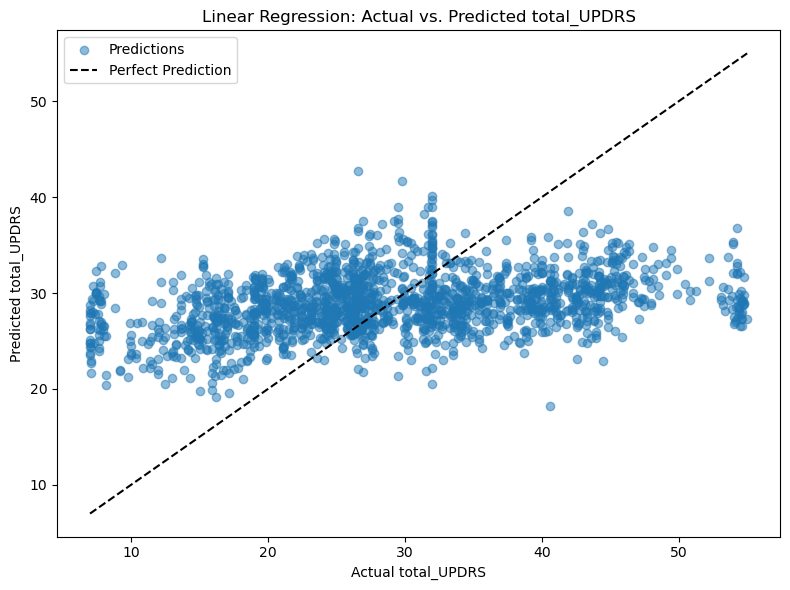

In [20]:
# Make predictions using the testing data

plt.figure(figsize=(8, 6))

# Plot actual values against predicted values
plt.scatter(y_test,test_pred,alpha=0.5,label='Predictions')

# Add the perfect prediction reference line
minimum = min(y_test.min(), test_pred.min())
maximum = max(y_test.max(), test_pred.max())

plt.plot([minimum, maximum],[minimum, maximum],linestyle='--',label='Perfect Prediction',color='black')

plt.title('Linear Regression: Actual vs. Predicted total_UPDRS')
plt.xlabel('Actual total_UPDRS')
plt.ylabel('Predicted total_UPDRS')
plt.legend()
plt.tight_layout()
plt.show()

### Actual vs Predicted total_UPDRS

The graph shows that the linear regression model captures the general trend, but its predictions are concentrated around approximately 20 to 35 total_UPDRS. The model tends to overpredict lower actual values and underpredict higher actual values, since many points fall above the perfect-prediction line on the left and below it on the right.

### Residual Analysis 

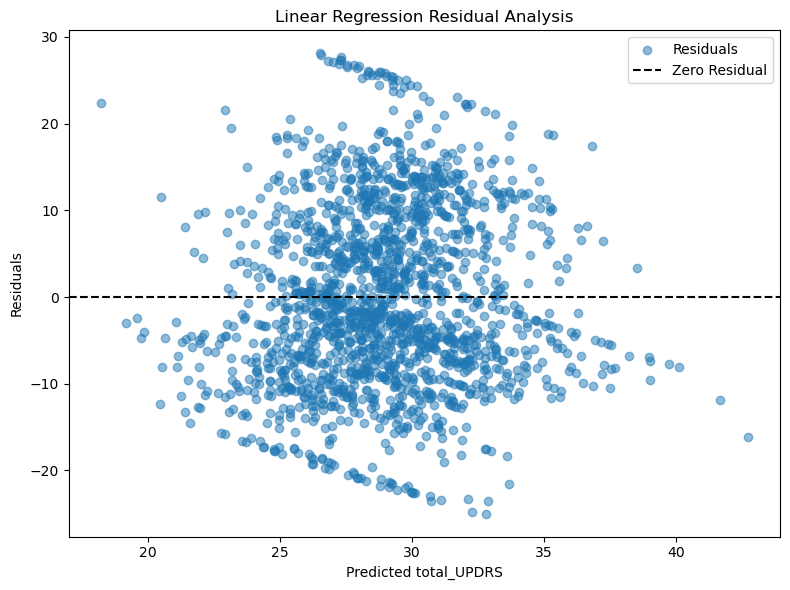

In [21]:
# Calculate residuals
residuals = y_test - test_pred

plt.figure(figsize=(8, 6))

# Plot predicted values against residuals
plt.scatter(test_pred,residuals,alpha=0.5,label='Residuals')

# Add the zero residual reference line
plt.axhline(y=0,linestyle='--',color='black',label='Zero Residual')

plt.title('Linear Regression Residual Analysis')
plt.xlabel('Predicted total_UPDRS')
plt.ylabel('Residuals')
plt.legend()
plt.tight_layout()
plt.show()

### Residual Graph Analysis

The residuals are spread above and below zero, but they form a noticeable pattern. This means the model’s predictions are not equally accurate across all values and the linear regression may not fit the data very well.

### LInear Regression Model Analysis

The linear regression model performed poorly because it explained only about 9.3% of the variation in the training data and 11.3% in the testing data. The test MAE of 8.489 means the model’s predictions were off by about 8.5 total_UPDRS points on average. Since the training and testing results are very similar, the model does not appear to be overfitting; instead, it may be underfitting because the relationship between the voice measures and total_UPDRS may not be strongly linear.

I used all 16 voice measures provided to complete a baseline model, but the low R squared and relatively high MAE suggest that a nonlinear model may better capture the relationship between the voice measurements and total_UPDRS.

# Builidng Regression Tree Model

In [22]:
from sklearn import tree

In [23]:
reg_tm = tree.DecisionTreeRegressor(min_samples_leaf= 5, random_state= 101)

reg_tm.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",101
,"max_

In [24]:
importance_tree = pd.DataFrame({'Predictor': X.columns,'Importance': reg_tm.feature_importances_})

importance_tree = importance_tree.sort_values('Importance',ascending=False)

importance_tree['Importance %'] = round(importance_tree['Importance'] * 100,3)

importance_tree

,Predictor,Importance,Importance %
14,DFA,0.189954,18.995
12,HNR,0.145805,14.580
1,Jitter(Abs),0.116682,11.668
15,PPE,0.108943,10.894
13,RPDE,0.074422,7.442
11,NHR,0.065210,6.521
9,Shimmer:APQ11,0.061748,6.175
0,Jitter(%),0.041045,4.105
8,Shimmer:APQ5,0.032478,3.248
10,Shimmer:DDA,0.030385,3.038


### Cross Validation - Regression Tree Model

In [25]:
# created a function for cross validation to give us the scores of R squared and the average of it for regression tree model

def cross_validation_reg_tm():
    
    cv_scores = cross_val_score(reg_tm, X_train, y_train, cv=5, scoring= 'r2')
    
    print('Cross-validation R² scores:', cv_scores)
    print('Average cross-validation R²:', round(cv_scores.mean(), 3))

cross_validation_reg_tm()

Cross-validation R² scores: [-0.14476852 -0.02056661 -0.07817041  0.08280321  0.04891789]
Average cross-validation R²: -0.022


### Model Evaluation - Regression Tree Model function

In [26]:
# created a function to evaluate the regression tree model

def evaluate_regression_tree(reg_tm, X_train, X_test, y_train, y_test):

    # Making predictions
    train_pred = reg_tm.predict(X_train)
    test_pred = reg_tm.predict(X_test)

    # Calculating R-squared scores
    train_r2 = metrics.r2_score(y_train, train_pred)
    test_r2 = metrics.r2_score(y_test, test_pred)

    # Calculating Mean Squared Error
    train_mse = metrics.mean_squared_error(y_train, train_pred)
    test_mse = metrics.mean_squared_error(y_test, test_pred)

    # Calculating Root Mean Squared Error
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    # Calculating Mean Absolute Error
    train_mae = metrics.mean_absolute_error(y_train, train_pred)
    test_mae = metrics.mean_absolute_error(y_test, test_pred)

    # Displaying training results
    print('Training Data Results:')
    print(f'R² Score: {train_r2:.3f}')
    print(f'Mean Squared Error: {train_mse:.3f}')
    print(f'Root Mean Squared Error: {train_rmse:.3f}')
    print(f'Mean Absolute Error: {train_mae:.3f}')

    # Displaying testing results
    print('\nTesting Data Results:')
    print(f'R² Score: {test_r2:.3f}')
    print(f'Mean Squared Error: {test_mse:.3f}')
    print(f'Root Mean Squared Error: {test_rmse:.3f}')
    print(f'Mean Absolute Error: {test_mae:.3f}')

    # Comparing actual and predicted test values
    prediction_results = pd.DataFrame({'Actual total_UPDRS': y_test.reset_index(drop=True),'Predicted total_UPDRS': test_pred})

    # Calculating residuals
    prediction_results['Residual'] = (prediction_results['Actual total_UPDRS']- prediction_results['Predicted total_UPDRS'])

    print('\nSample Test Predictions:')
    print(prediction_results.head(10).round(3))

    return train_pred, test_pred, prediction_results

reg_tm_train_pred, reg_tm_test_pred, reg_tm_prediction_results = (evaluate_regression_tree(reg_tm,X_train,X_test,y_train,y_test))

Training Data Results:
R² Score: 0.776
Mean Squared Error: 25.295
Root Mean Squared Error: 5.029
Mean Absolute Error: 3.556

Testing Data Results:
R² Score: -0.005
Mean Squared Error: 119.038
Root Mean Squared Error: 10.910
Mean Absolute Error: 8.149

Sample Test Predictions:
   Actual total_UPDRS  Predicted total_UPDRS  Residual
0              39.292                 41.452    -2.160
1              29.102                 24.121     4.981
2              24.942                 36.877   -11.935
3              23.982                 39.696   -15.714
4              32.942                 27.829     5.113
5               8.164                 11.399    -3.235
6              31.876                 40.376    -8.500
7              16.326                 18.816    -2.490
8              44.253                 23.922    20.331
9              34.044                 24.107     9.937


### Visual of Regression Tree

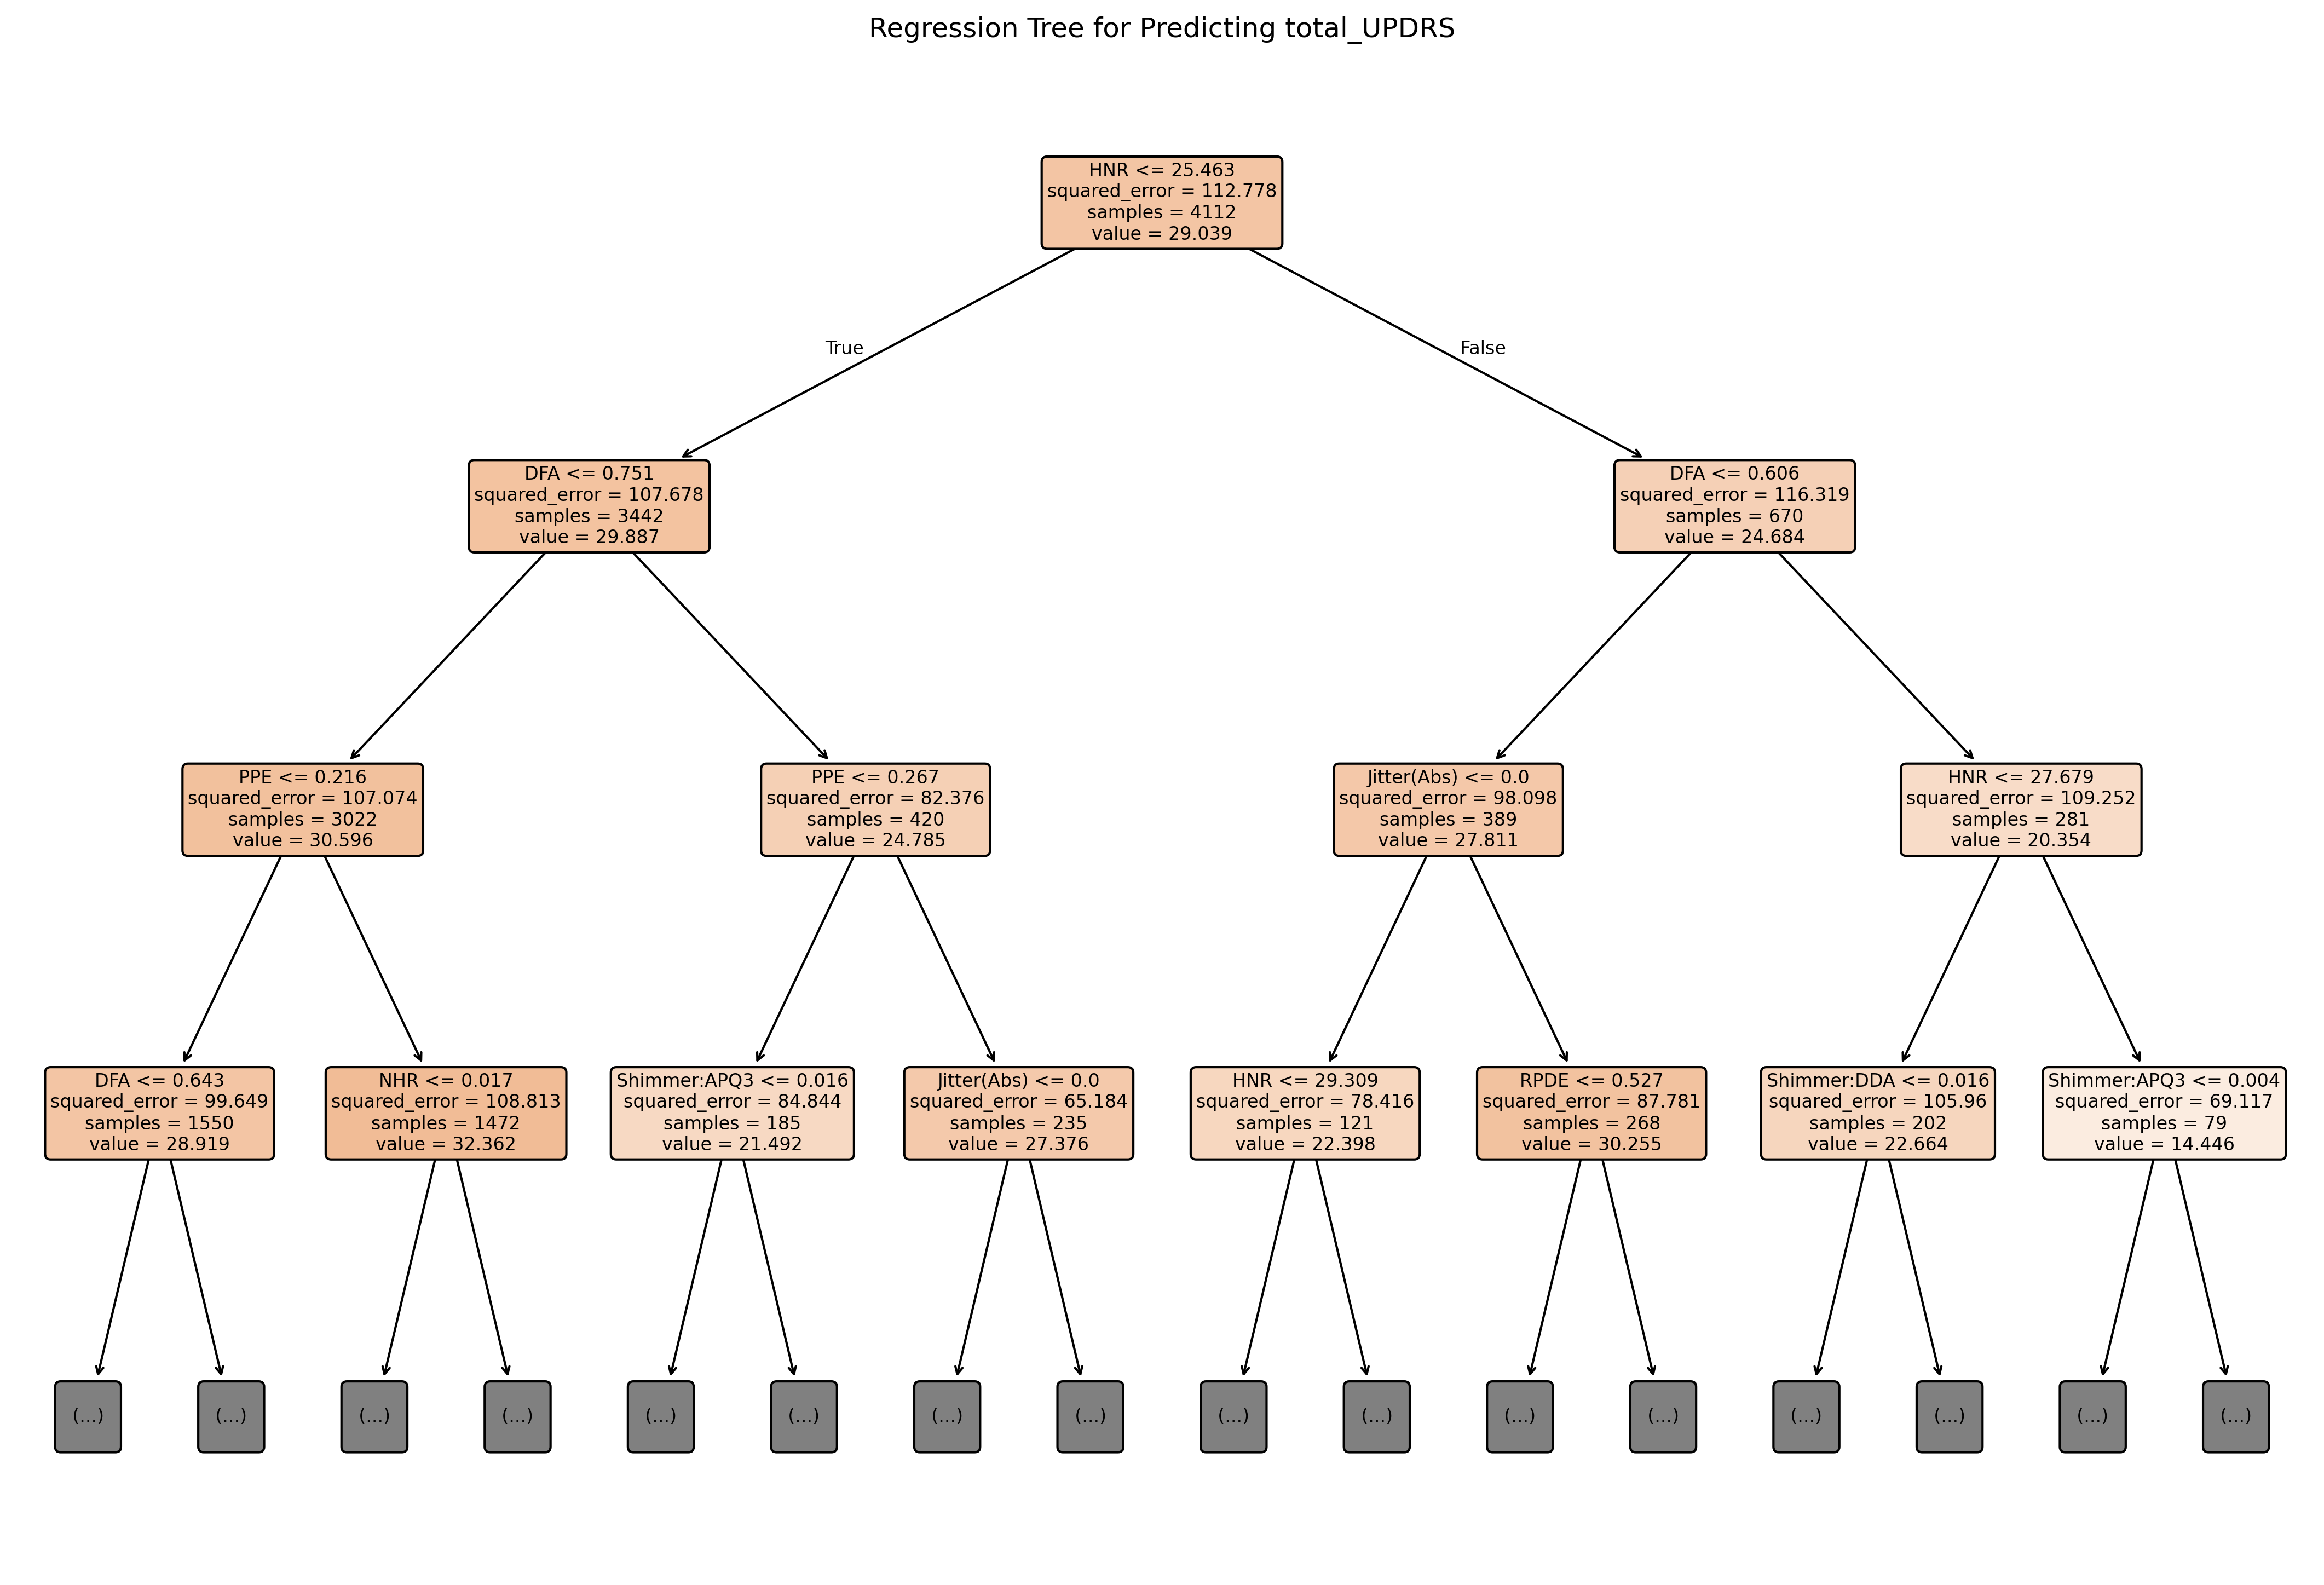

In [27]:
from graphviz import Source

plt.figure(figsize=(18, 12), dpi= 300)

tree.plot_tree(reg_tm,feature_names=X.columns,filled=True,rounded=True,max_depth=3,fontsize=8)

plt.title("Regression Tree for Predicting total_UPDRS")
plt.show()

### Regression Tree Model Analysis

The regression tree performed well on the training data, explaining about 77.6% of the variation with a training MAE of 3.556. However, its testing R sqaured was -0.005 and the testing MAE increased to 8.149, showing that the model performed much worse on unseen data. This large difference between training and testing results suggests that the regression tree is overfitting the training data.

# Building Neural Network Model

In [28]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn import neural_network

In [29]:
scaler = MinMaxScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
nn_model = neural_network.MLPRegressor(hidden_layer_sizes=10, activation='logistic',max_iter=10000,random_state=101)

nn_model.fit(X_train_scaled, y_train)

nn_model.coefs_

C:\Users\noahh\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10000) reached and the optimization hasn't converged yet.
  warnings.warn(


[array([[  6.20870141, -10.29572598,   3.69068175,  13.80515956,
           8.47947358,   7.21671763,  11.07321309,  -0.16449648,
           7.60393959,  13.96105469],
        [  2.79984607, -23.6421521 ,  16.48924334, -13.87248598,
         -16.84147491, -22.71644094,   7.00669688,  42.48359929,
         -21.07627173,  36.85632097],
        [ -4.29369067,  -4.13749311,  -8.01303612,  13.78733457,
           9.57002686,  -1.23951707,  -0.25769861,   0.28204649,
           9.59398322,   5.11418633],
        [ 10.43304586,  -4.74708769,  16.12707572,  17.7949118 ,
          10.66947372,   8.25333237,  16.20639303,   3.96847039,
          14.04212676,  25.53775031],
        [ -4.55024351,  -4.30265133,  -7.60347626,  14.30844129,
           9.63838457,  -1.60932496,  -0.10909814,   0.14357256,
           9.66830761,   5.18919631],
        [  0.58385438,  -0.15624317,  -1.20047953,   4.48211501,
           4.8125363 ,  -3.2560685 ,  -2.32471846,   0.40360512,
           6.84287352,  -4.847

In [31]:
nn_model.intercepts_

[array([ 8.75088245,  3.45285797,  8.59104433,  6.16284771, -1.18359312,
         6.32565893,  7.99327218, -1.92675677,  6.29588019,  6.96290761]),
 array([-10.37583329])]

### Cross Validation - Neural Network

In [32]:
from sklearn.pipeline import Pipeline

In [33]:
def cross_validation_nn():

    nn_pipeline = Pipeline([('scaler', MinMaxScaler()),('neural_network', MLPRegressor(hidden_layer_sizes=(100,),max_iter=10000,random_state=101))])

    cv_scores = cross_val_score(nn_pipeline,X_train,y_train,cv=5,scoring='r2')

    print('Cross-validation R² scores:', cv_scores)
    print('Average cross-validation R²:', round(cv_scores.mean(), 3))

cross_validation_nn()

Cross-validation R² scores: [0.17727544 0.16609442 0.20692321 0.18320808 0.21149824]
Average cross-validation R²: 0.189


### Model Evaluation - Neural Network

In [34]:
def evaluate_neural_network(nn_model,X_train_scaled,X_test_scaled,y_train,y_test):

    # Making predictions
    train_pred = nn_model.predict(X_train_scaled)
    test_pred = nn_model.predict(X_test_scaled)

    # Calculating R-squared scores
    train_r2 = metrics.r2_score(y_train, train_pred)
    test_r2 = metrics.r2_score(y_test, test_pred)

    # Calculating Mean Squared Error
    train_mse = metrics.mean_squared_error(y_train, train_pred)
    test_mse = metrics.mean_squared_error(y_test, test_pred)

    # Calculating Root Mean Squared Error
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    # Calculating Mean Absolute Error
    train_mae = metrics.mean_absolute_error(y_train, train_pred)
    test_mae = metrics.mean_absolute_error(y_test, test_pred)

    # Displaying training results
    print('Training Data Results:')
    print(f'R² Score: {train_r2:.3f}')
    print(f'Mean Squared Error: {train_mse:.3f}')
    print(f'Root Mean Squared Error: {train_rmse:.3f}')
    print(f'Mean Absolute Error: {train_mae:.3f}')

    # Displaying testing results
    print('\nTesting Data Results:')
    print(f'R² Score: {test_r2:.3f}')
    print(f'Mean Squared Error: {test_mse:.3f}')
    print(f'Root Mean Squared Error: {test_rmse:.3f}')
    print(f'Mean Absolute Error: {test_mae:.3f}')

    # Comparing actual and predicted test values
    prediction_results = pd.DataFrame({
        'Actual total_UPDRS': y_test.reset_index(drop=True),'Predicted total_UPDRS': test_pred})

    # Calculating residuals
    prediction_results['Residual'] = (prediction_results['Actual total_UPDRS']- prediction_results['Predicted total_UPDRS'])

    print('\nSample Test Predictions:')
    print(prediction_results.head(10).round(3))

    return train_pred, test_pred, prediction_results

nn_train_pred, nn_test_pred, nn_prediction_results = (evaluate_neural_network(nn_model,X_train_scaled,X_test_scaled,y_train,y_test))

Training Data Results:
R² Score: 0.242
Mean Squared Error: 85.539
Root Mean Squared Error: 9.249
Mean Absolute Error: 7.454

Testing Data Results:
R² Score: 0.216
Mean Squared Error: 92.830
Root Mean Squared Error: 9.635
Mean Absolute Error: 7.879

Sample Test Predictions:
   Actual total_UPDRS  Predicted total_UPDRS  Residual
0              39.292                 31.649     7.643
1              29.102                 19.407     9.695
2              24.942                 31.742    -6.800
3              23.982                 27.884    -3.902
4              32.942                 24.992     7.950
5               8.164                 22.108   -13.943
6              31.876                 28.849     3.027
7              16.326                 19.024    -2.698
8              44.253                 33.859    10.394
9              34.044                 31.491     2.553


### Neural Network Analysis

The neural network performed better than the other models, explaining about 24.2% of the variation in the training data and 21.6% in the testing data. Its testing MAE was 7.879, meaning its predictions were off by about 7.9 total_UPDRS points on average. Because the training and testing results are close, the model does not appear to be strongly overfitting and shows more consistent performance on unseen data.

# Neural Network Optimization

In [35]:
# from sklearn.model_selection import GridSearchCV

In [36]:
# tuned_parameters = {'hidden_layer_sizes': [(10,),(15,),(20,),(25,),(30,),(35,)], 'activation': ['logistic','tanh','relu']}

In [37]:
# nn_optimizer = GridSearchCV(MLPRegressor(max_iter= 10000, random_state= 101), param_grid= tuned_parameters, cv= 5, scoring= 'r2')

# nn_optimizer.fit(X_train_scaled, y_train)

# print('Best parameters:', nn_optimizer.best_params_)
# print('Best cross-validation R²:', round(nn_optimizer.best_score_, 3))

# Comparing Models Performance with MAE

In [38]:
# created a data frame to compare all models against each other

model_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Regression Tree Model', 'Neural Network'],
    'Train MAE': [8.252, 3.556,7.454],
    'Test MAE': [8.489,8.149,7.879]})

model_results

,Model,Train MAE,Test MAE
0,Linear Regression,8.252,8.489
1,Regression Tree Model,3.556,8.149
2,Neural Network,7.454,7.879


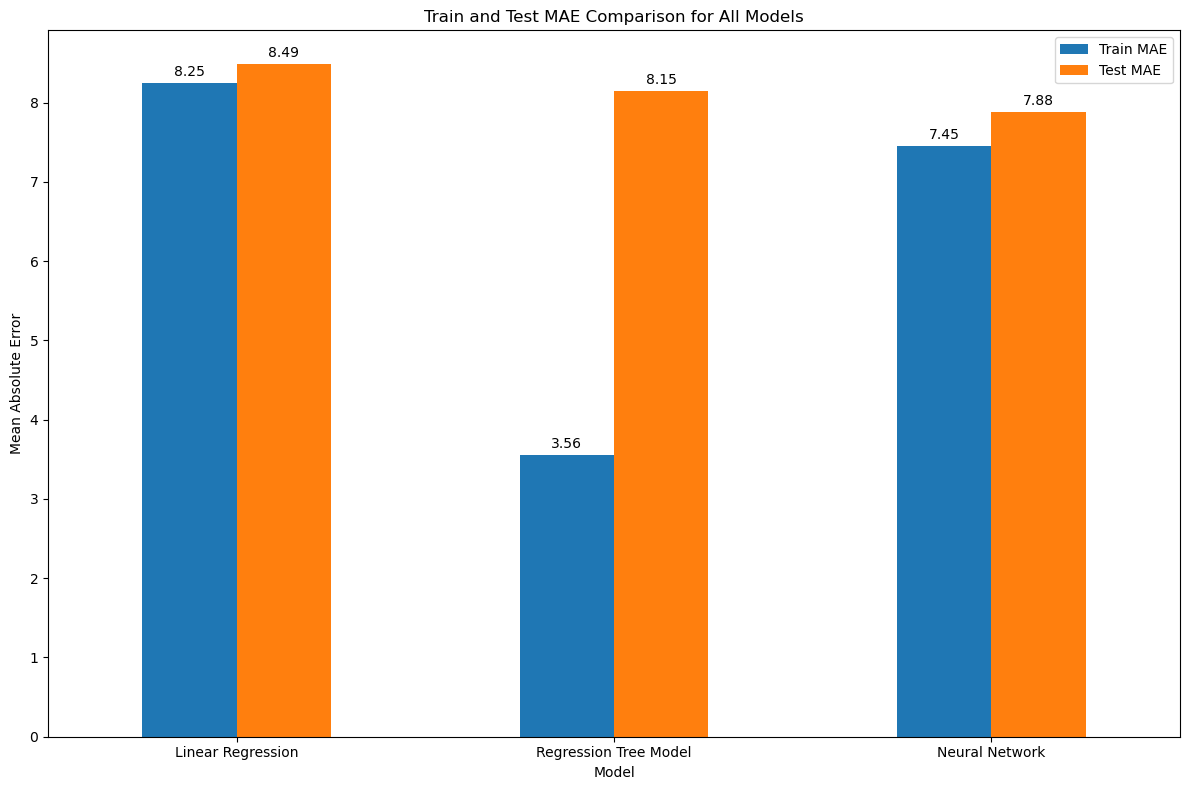

In [39]:
# creating a bar chart to visually compare each model

ax = model_results.plot(x='Model',y=['Train MAE', 'Test MAE'],kind='bar',figsize=(12, 8))

for container in ax.containers:
    ax.bar_label(container, fmt = '%.2f', padding = 3)

plt.title('Train and Test MAE Comparison for All Models')
plt.ylabel('Mean Absolute Error')
plt.xlabel('Model')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.legend()
plt.show()

Using MAE, the neural network performed best because it had the lowest testing MAE of 7.88. This means its predictions were off by about 7.88 total_UPDRS points on average.

The regression tree had the lowest training MAE at 3.56, but its testing MAE increased sharply to 8.15, which means it was probably overfitting. The linear regression model had the highest testing MAE at 8.49, making it the weakest model on unseen data. Overall, the neural network gave the best balance between training and testing performance and generalized better than the other models.